In [1]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 2.3.3
NumPy version: 2.2.6


In [2]:
import pandas as pd
import numpy as np

# Reproducible results
np.random.seed(42)

# Number of orders
n_orders = 5000

# Food items
food_items = [
    "Chicken Biryani",
    "Chicken Fried Rice",
    "Chicken Noodles",
    "Chicken 65",
    "Chicken Grill",
    "Mutton Biryani",
    "Veg Biryani",
    "Parotta",
    "Dosa",
    "Idli",
    "Fried Rice",
    "Noodles",
    "Paneer Butter Masala",
    "Veg Meals"
]

# Food categories
categories = {
    "Chicken Biryani": "Chicken",
    "Chicken Fried Rice": "Chicken",
    "Chicken Noodles": "Chicken",
    "Chicken 65": "Chicken",
    "Chicken Grill": "Chicken",
    "Mutton Biryani": "Mutton",
    "Veg Biryani": "Vegetarian",
    "Parotta": "Vegetarian",
    "Dosa": "Vegetarian",
    "Idli": "Vegetarian",
    "Fried Rice": "Vegetarian",
    "Noodles": "Vegetarian",
    "Paneer Butter Masala": "Vegetarian",
    "Veg Meals": "Vegetarian"
}

# Prices
prices = {
    "Chicken Biryani": 180,
    "Chicken Fried Rice": 160,
    "Chicken Noodles": 150,
    "Chicken 65": 140,
    "Chicken Grill": 220,
    "Mutton Biryani": 240,
    "Veg Biryani": 130,
    "Parotta": 60,
    "Dosa": 50,
    "Idli": 40,
    "Fried Rice": 120,
    "Noodles": 110,
    "Paneer Butter Masala": 170,
    "Veg Meals": 100
}

# Generate dates
dates = pd.date_range(
    start="2025-01-01",
    end="2025-12-31",
    periods=n_orders
)

# Generate food items
food = np.random.choice(
    food_items,
    size=n_orders
)

# Generate quantities
quantity = np.random.randint(
    1,
    6,
    size=n_orders
)

# Create dataframe
df = pd.DataFrame({
    "Order_ID": range(1, n_orders + 1),
    "Order_Date": dates,
    "Food_Item": food,
    "Quantity": quantity
})

# Add category
df["Category"] = df["Food_Item"].map(categories)

# Add unit price
df["Unit_Price"] = df["Food_Item"].map(prices)

# Calculate total amount
df["Total_Amount"] = (
    df["Quantity"] * df["Unit_Price"]
)

# Add day
df["Day"] = df["Order_Date"].dt.day_name()

# Add meal time
meal_times = [
    "Breakfast",
    "Lunch",
    "Dinner"
]

df["Meal_Time"] = np.random.choice(
    meal_times,
    size=n_orders,
    p=[0.20, 0.40, 0.40]
)

# Add customer type
df["Customer_Type"] = np.random.choice(
    ["New", "Regular"],
    size=n_orders,
    p=[0.35, 0.65]
)

# Preparation quantity
df["Preparation_Quantity"] = (
    df["Quantity"] +
    np.random.randint(0, 4, size=n_orders)
)

# Wasted quantity
df["Wasted_Quantity"] = (
    df["Preparation_Quantity"] -
    df["Quantity"]
)

# Display dataset
df.head()

,Order_ID,Order_Date,Food_Item,Quantity,Category,Unit_Price,Total_Amount,Day,Meal_Time,Customer_Type,Preparation_Quantity,Wasted_Quantity
0,1,2025-01-01 00:00:00.000000000,Veg Biryani,5,Vegetarian,130,650,Wednesday,Breakfast,New,8,3
1,2,2025-01-01 01:44:51.178235647,Chicken 65,2,Chicken,140,280,Wednesday,Dinner,New,2,0
2,3,2025-01-01 03:29:42.356471294,Paneer Butter Masala,4,Vegetarian,170,680,Wednesday,Dinner,New,5,1
3,4,2025-01-01 05:14:33.534706941,Fried Rice,1,Vegetarian,120,120,Wednesday,Breakfast,Regular,3,2
4,5,2025-01-01 06:59:24.712942588,Parotta,3,Vegetarian,60,180,Wednesday,Breakfast,Regular,4,1


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 5000
Columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order_ID              5000 non-null   int64         
 1   Order_Date            5000 non-null   datetime64[ns]
 2   Food_Item             5000 non-null   object        
 3   Quantity              5000 non-null   int32         
 4   Category              5000 non-null   object        
 5   Unit_Price            5000 non-null   int64         
 6   Total_Amount          5000 non-null   int64         
 7   Day                   5000 non-null   object        
 8   Meal_Time             5000 non-null   object        
 9   Customer_Type         5000 non-null   object        
 10  Preparation_Quantity  5000 non-null   int32         
 11  Wasted_Quantity       5000 non-null   int32         
dtypes: datetime64[ns](1), int32(3), int64(3), object(5)
m

In [4]:
file_path = "../data/raw/restaurant_orders.csv"

df.to_csv(
    file_path,
    index=False
)

print("Dataset saved successfully!")
print(file_path)

Dataset saved successfully!
../data/raw/restaurant_orders.csv


In [5]:
# Check dataset shape
print("Dataset Shape:", df.shape)

# Check column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Check data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (5000, 12)

Column Names:
['Order_ID', 'Order_Date', 'Food_Item', 'Quantity', 'Category', 'Unit_Price', 'Total_Amount', 'Day', 'Meal_Time', 'Customer_Type', 'Preparation_Quantity', 'Wasted_Quantity']

Missing Values:
Order_ID                0
Order_Date              0
Food_Item               0
Quantity                0
Category                0
Unit_Price              0
Total_Amount            0
Day                     0
Meal_Time               0
Customer_Type           0
Preparation_Quantity    0
Wasted_Quantity         0
dtype: int64

Duplicate Rows:
0

Data Types:
Order_ID                         int64
Order_Date              datetime64[ns]
Food_Item                       object
Quantity                         int32
Category                        object
Unit_Price                       int64
Total_Amount                     int64
Day                             object
Meal_Time                       object
Customer_Type                   object
Preparation_Quantity 

In [6]:
df.describe()

,Order_ID,Order_Date,Quantity,Unit_Price,Total_Amount,Preparation_Quantity,Wasted_Quantity
count,5000.000000,5000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,2025-07-02 00:00:00,2.988200,134.268000,400.55800,4.500400,1.512200
min,1.000000,2025-01-01 00:00:00,1.000000,40.000000,40.00000,1.000000,0.000000
25%,1250.750000,2025-04-02 00:00:00,2.000000,100.000000,180.00000,3.000000,1.000000
50%,2500.500000,2025-07-02 00:00:00.000000256,3.000000,140.000000,330.00000,5.000000,2.000000
75%,3750.250000,2025-10-01 00:00:00,4.000000,170.000000,560.00000,6.000000,3.000000
max,5000.000000,2025-12-31 00:00:00,5.000000,240.000000,1200.00000,8.000000,3.000000
std,1443.520003,NaN,1.414094,57.704854,267.41655,1.794058,1.121295


In [7]:
print("Number of Food Items:", df["Food_Item"].nunique())

print("\nFood Items:")
print(df["Food_Item"].unique())

Number of Food Items: 14

Food Items:
['Veg Biryani' 'Chicken 65' 'Paneer Butter Masala' 'Fried Rice' 'Parotta'
 'Chicken Grill' 'Idli' 'Chicken Noodles' 'Mutton Biryani'
 'Chicken Fried Rice' 'Noodles' 'Veg Meals' 'Chicken Biryani' 'Dosa']


In [8]:
print(df["Category"].value_counts())

Category
Vegetarian    2826
Chicken       1816
Mutton         358
Name: count, dtype: int64


In [9]:
# Total quantity ordered for each food item

item_demand = (
    df.groupby("Food_Item")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(item_demand)

Food_Item
Noodles                 1184
Chicken Grill           1131
Chicken Noodles         1125
Chicken Biryani         1118
Paneer Butter Masala    1118
Parotta                 1096
Dosa                    1068
Veg Meals               1054
Mutton Biryani          1052
Idli                    1045
Chicken Fried Rice      1022
Veg Biryani             1000
Chicken 65               998
Fried Rice               930
Name: Quantity, dtype: int32


In [10]:
top_5_items = item_demand.head(5)

print("Top 5 Most-Ordered Food Items:")
print(top_5_items)

Top 5 Most-Ordered Food Items:
Food_Item
Noodles                 1184
Chicken Grill           1131
Chicken Noodles         1125
Chicken Biryani         1118
Paneer Butter Masala    1118
Name: Quantity, dtype: int32


In [11]:
bottom_5_items = item_demand.tail(5)

print("Bottom 5 Least-Ordered Food Items:")
print(bottom_5_items)

Bottom 5 Least-Ordered Food Items:
Food_Item
Idli                  1045
Chicken Fried Rice    1022
Veg Biryani           1000
Chicken 65             998
Fried Rice             930
Name: Quantity, dtype: int32


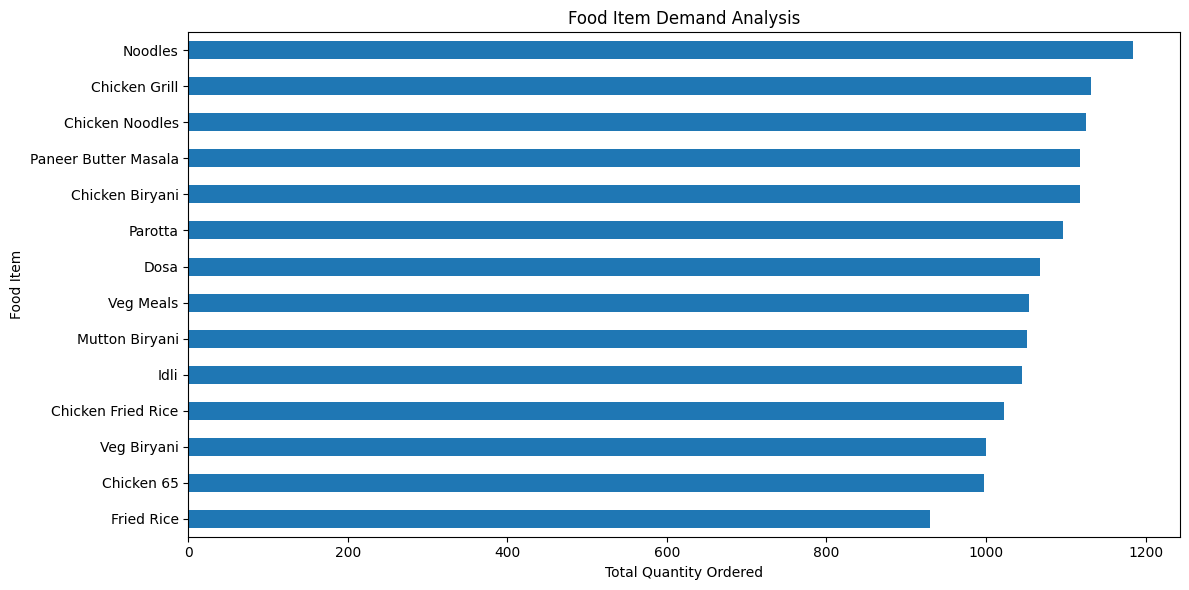

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

item_demand.sort_values().plot(
    kind="barh"
)

plt.title("Food Item Demand Analysis")
plt.xlabel("Total Quantity Ordered")
plt.ylabel("Food Item")

plt.tight_layout()
plt.show()

In [13]:
demand_analysis = (
    df.groupby("Food_Item")
    .agg(
        Total_Orders=("Quantity", "sum"),
        Total_Revenue=("Total_Amount", "sum"),
        Total_Waste=("Wasted_Quantity", "sum")
    )
    .sort_values(
        "Total_Orders",
        ascending=False
    )
)

demand_analysis

,Total_Orders,Total_Revenue,Total_Waste
Food_Item,,,
Noodles,1184,130240,586
Chicken Grill,1131,248820,571
Chicken Noodles,1125,168750,515
Chicken Biryani,1118,201240,560
Paneer Butter Masala,1118,190060,511
Parotta,1096,65760,572
Dosa,1068,53400,518
Veg Meals,1054,105400,568
Mutton Biryani,1052,252480,565


In [14]:
waste_analysis = (
    df.groupby("Food_Item")
    .agg(
        Total_Ordered=("Quantity", "sum"),
        Total_Prepared=("Preparation_Quantity", "sum"),
        Total_Wasted=("Wasted_Quantity", "sum")
    )
    .sort_values(
        "Total_Wasted",
        ascending=False
    )
)

waste_analysis

,Total_Ordered,Total_Prepared,Total_Wasted
Food_Item,,,
Noodles,1184,1770,586
Parotta,1096,1668,572
Chicken Grill,1131,1702,571
Veg Meals,1054,1622,568
Mutton Biryani,1052,1617,565
Chicken Biryani,1118,1678,560
Chicken Fried Rice,1022,1568,546
Idli,1045,1584,539
Dosa,1068,1586,518


In [15]:
waste_analysis["Waste_Percentage"] = (
    waste_analysis["Total_Wasted"]
    / waste_analysis["Total_Prepared"]
    * 100
)

waste_analysis = waste_analysis.sort_values(
    "Waste_Percentage",
    ascending=False
)

waste_analysis

,Total_Ordered,Total_Prepared,Total_Wasted,Waste_Percentage
Food_Item,,,,
Veg Meals,1054,1622,568,35.018496
Mutton Biryani,1052,1617,565,34.941249
Chicken Fried Rice,1022,1568,546,34.821429
Fried Rice,930,1421,491,34.553132
Parotta,1096,1668,572,34.292566
Chicken 65,998,1515,517,34.125413
Idli,1045,1584,539,34.027778
Chicken Grill,1131,1702,571,33.548766
Veg Biryani,1000,1502,502,33.422104


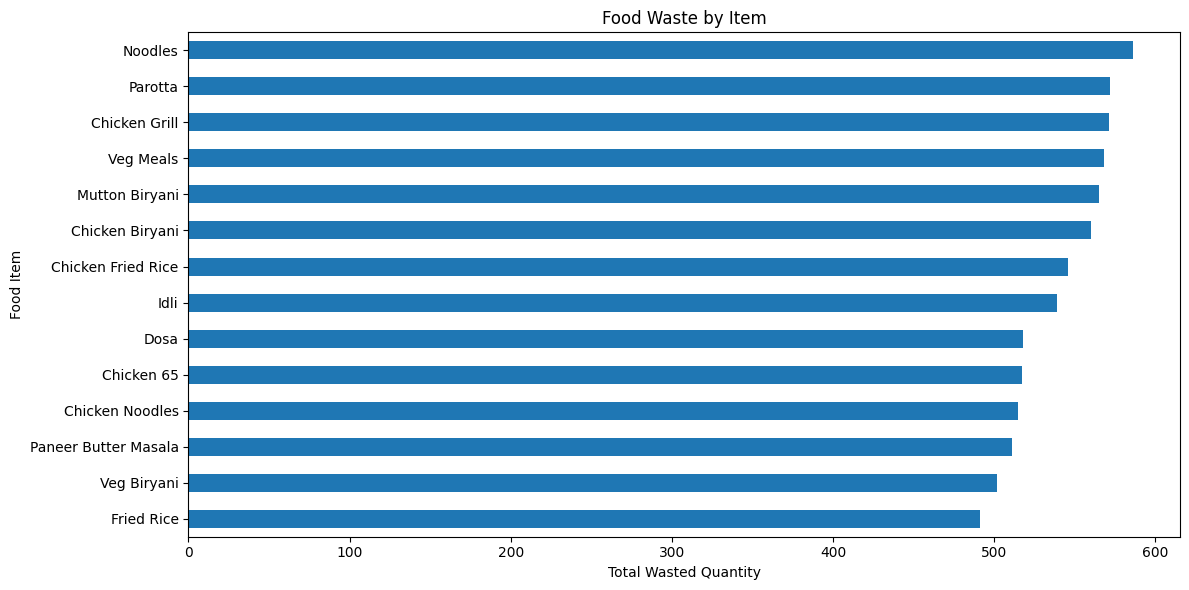

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

waste_analysis["Total_Wasted"].sort_values().plot(
    kind="barh"
)

plt.title("Food Waste by Item")
plt.xlabel("Total Wasted Quantity")
plt.ylabel("Food Item")

plt.tight_layout()
plt.show()

In [17]:
high_waste_items = waste_analysis[
    waste_analysis["Waste_Percentage"] > 10
]

print("High-Waste Food Items:")
print(high_waste_items)

High-Waste Food Items:
                      Total_Ordered  Total_Prepared  Total_Wasted  \
Food_Item                                                           
Veg Meals                      1054            1622           568   
Mutton Biryani                 1052            1617           565   
Chicken Fried Rice             1022            1568           546   
Fried Rice                      930            1421           491   
Parotta                        1096            1668           572   
Chicken 65                      998            1515           517   
Idli                           1045            1584           539   
Chicken Grill                  1131            1702           571   
Veg Biryani                    1000            1502           502   
Chicken Biryani                1118            1678           560   
Noodles                        1184            1770           586   
Dosa                           1068            1586           518   
Chicken Noo

In [18]:
business_analysis = (
    df.groupby("Food_Item")
    .agg(
        Total_Ordered=("Quantity", "sum"),
        Total_Prepared=("Preparation_Quantity", "sum"),
        Total_Wasted=("Wasted_Quantity", "sum"),
        Total_Revenue=("Total_Amount", "sum")
    )
)

business_analysis["Waste_Percentage"] = (
    business_analysis["Total_Wasted"]
    / business_analysis["Total_Prepared"]
    * 100
)

business_analysis = business_analysis.sort_values(
    "Total_Wasted",
    ascending=False
)

business_analysis

,Total_Ordered,Total_Prepared,Total_Wasted,Total_Revenue,Waste_Percentage
Food_Item,,,,,
Noodles,1184,1770,586,130240,33.107345
Parotta,1096,1668,572,65760,34.292566
Chicken Grill,1131,1702,571,248820,33.548766
Veg Meals,1054,1622,568,105400,35.018496
Mutton Biryani,1052,1617,565,252480,34.941249
Chicken Biryani,1118,1678,560,201240,33.373063
Chicken Fried Rice,1022,1568,546,163520,34.821429
Idli,1045,1584,539,41800,34.027778
Dosa,1068,1586,518,53400,32.660782


In [19]:
# Filter chicken items
chicken_df = df[df["Category"] == "Chicken"].copy()

print("Chicken Orders Dataset:")
print(chicken_df.head())

print("\nNumber of Chicken Order Records:", len(chicken_df))

Chicken Orders Dataset:
    Order_ID                    Order_Date        Food_Item  Quantity  \
1          2 2025-01-01 01:44:51.178235647       Chicken 65         2   
6          7 2025-01-01 10:29:07.069413882    Chicken Grill         3   
9         10 2025-01-01 15:43:40.604120824  Chicken Noodles         5   
14        15 2025-01-02 00:27:56.495299059    Chicken Grill         5   
15        16 2025-01-02 02:12:47.673534706       Chicken 65         3   

   Category  Unit_Price  Total_Amount        Day Meal_Time Customer_Type  \
1   Chicken         140           280  Wednesday    Dinner           New   
6   Chicken         220           660  Wednesday    Dinner       Regular   
9   Chicken         150           750  Wednesday     Lunch       Regular   
14  Chicken         220          1100   Thursday    Dinner       Regular   
15  Chicken         140           420   Thursday    Dinner       Regular   

    Preparation_Quantity  Wasted_Quantity  
1                      2            

In [20]:
chicken_demand = (
    chicken_df.groupby("Food_Item")
    .agg(
        Total_Ordered=("Quantity", "sum"),
        Total_Revenue=("Total_Amount", "sum"),
        Total_Wasted=("Wasted_Quantity", "sum")
    )
    .sort_values(
        "Total_Ordered",
        ascending=False
    )
)

chicken_demand

,Total_Ordered,Total_Revenue,Total_Wasted
Food_Item,,,
Chicken Grill,1131,248820,571
Chicken Noodles,1125,168750,515
Chicken Biryani,1118,201240,560
Chicken Fried Rice,1022,163520,546
Chicken 65,998,139720,517


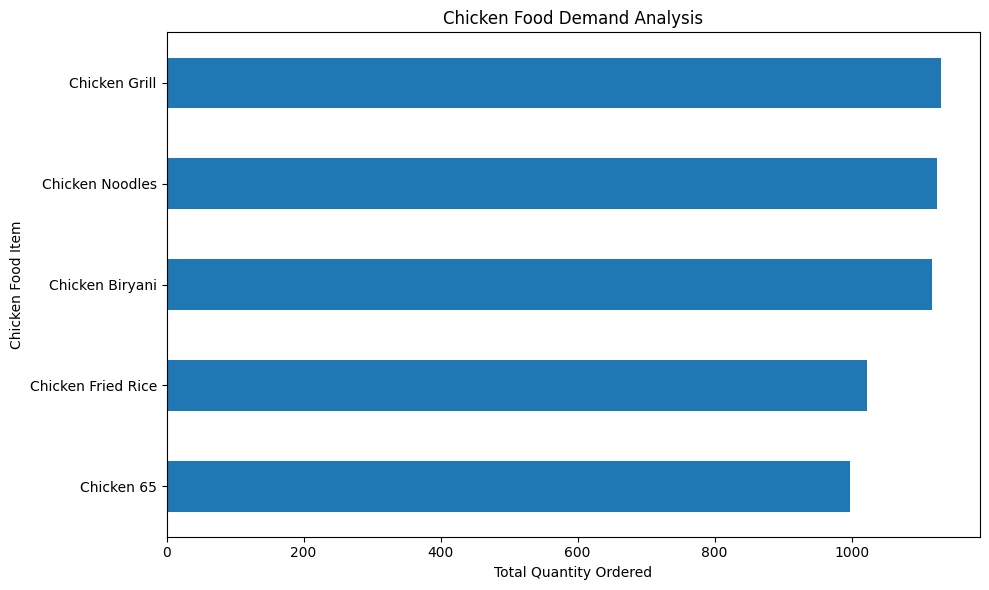

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

chicken_demand["Total_Ordered"].sort_values().plot(
    kind="barh"
)

plt.title("Chicken Food Demand Analysis")
plt.xlabel("Total Quantity Ordered")
plt.ylabel("Chicken Food Item")

plt.tight_layout()
plt.show()

In [22]:
chicken_waste = (
    chicken_df.groupby("Food_Item")
    .agg(
        Total_Ordered=("Quantity", "sum"),
        Total_Prepared=("Preparation_Quantity", "sum"),
        Total_Wasted=("Wasted_Quantity", "sum")
    )
)

chicken_waste["Waste_Percentage"] = (
    chicken_waste["Total_Wasted"]
    / chicken_waste["Total_Prepared"]
    * 100
)

chicken_waste = chicken_waste.sort_values(
    "Waste_Percentage",
    ascending=False
)

chicken_waste

,Total_Ordered,Total_Prepared,Total_Wasted,Waste_Percentage
Food_Item,,,,
Chicken Fried Rice,1022,1568,546,34.821429
Chicken 65,998,1515,517,34.125413
Chicken Grill,1131,1702,571,33.548766
Chicken Biryani,1118,1678,560,33.373063
Chicken Noodles,1125,1640,515,31.402439


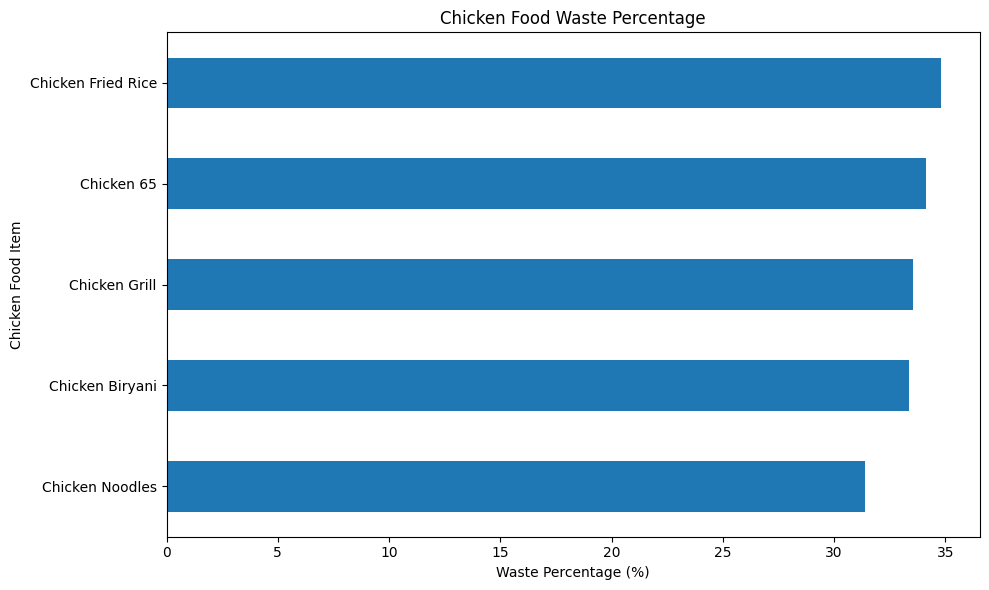

In [23]:
plt.figure(figsize=(10, 6))

chicken_waste["Waste_Percentage"].sort_values().plot(
    kind="barh"
)

plt.title("Chicken Food Waste Percentage")
plt.xlabel("Waste Percentage (%)")
plt.ylabel("Chicken Food Item")

plt.tight_layout()
plt.show()

In [24]:
high_demand_chicken = chicken_demand[
    chicken_demand["Total_Ordered"] >=
    chicken_demand["Total_Ordered"].median()
]

print("High-Demand Chicken Items:")
print(high_demand_chicken)

High-Demand Chicken Items:
                 Total_Ordered  Total_Revenue  Total_Wasted
Food_Item                                                  
Chicken Grill             1131         248820           571
Chicken Noodles           1125         168750           515
Chicken Biryani           1118         201240           560


In [25]:
high_waste_chicken = chicken_waste[
    chicken_waste["Waste_Percentage"] > 10
]

print("High-Waste Chicken Items:")
print(high_waste_chicken)

High-Waste Chicken Items:
                    Total_Ordered  Total_Prepared  Total_Wasted  \
Food_Item                                                         
Chicken Fried Rice           1022            1568           546   
Chicken 65                    998            1515           517   
Chicken Grill                1131            1702           571   
Chicken Biryani              1118            1678           560   
Chicken Noodles              1125            1640           515   

                    Waste_Percentage  
Food_Item                             
Chicken Fried Rice         34.821429  
Chicken 65                 34.125413  
Chicken Grill              33.548766  
Chicken Biryani            33.373063  
Chicken Noodles            31.402439  


In [26]:
chicken_business_analysis = (
    chicken_df.groupby("Food_Item")
    .agg(
        Total_Orders=("Quantity", "sum"),
        Total_Prepared=("Preparation_Quantity", "sum"),
        Total_Wasted=("Wasted_Quantity", "sum"),
        Total_Revenue=("Total_Amount", "sum")
    )
)

chicken_business_analysis["Waste_Percentage"] = (
    chicken_business_analysis["Total_Wasted"]
    / chicken_business_analysis["Total_Prepared"]
    * 100
)

chicken_business_analysis = (
    chicken_business_analysis
    .sort_values("Total_Orders", ascending=False)
)

chicken_business_analysis

,Total_Orders,Total_Prepared,Total_Wasted,Total_Revenue,Waste_Percentage
Food_Item,,,,,
Chicken Grill,1131,1702,571,248820,33.548766
Chicken Noodles,1125,1640,515,168750,31.402439
Chicken Biryani,1118,1678,560,201240,33.373063
Chicken Fried Rice,1022,1568,546,163520,34.821429
Chicken 65,998,1515,517,139720,34.125413


In [27]:
# Create month column
df["Month"] = df["Order_Date"].dt.month_name()

# Monthly demand
monthly_demand = (
    df.groupby("Month")["Quantity"]
    .sum()
)

monthly_demand

Month
April        1283
August       1286
December     1200
February     1186
January      1228
July         1273
June         1210
March        1279
May          1291
November     1218
October      1256
September    1231
Name: Quantity, dtype: int32

In [28]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_demand = monthly_demand.reindex(month_order)

monthly_demand

Month
January      1228
February     1186
March        1279
April        1283
May          1291
June         1210
July         1273
August       1286
September    1231
October      1256
November     1218
December     1200
Name: Quantity, dtype: int32

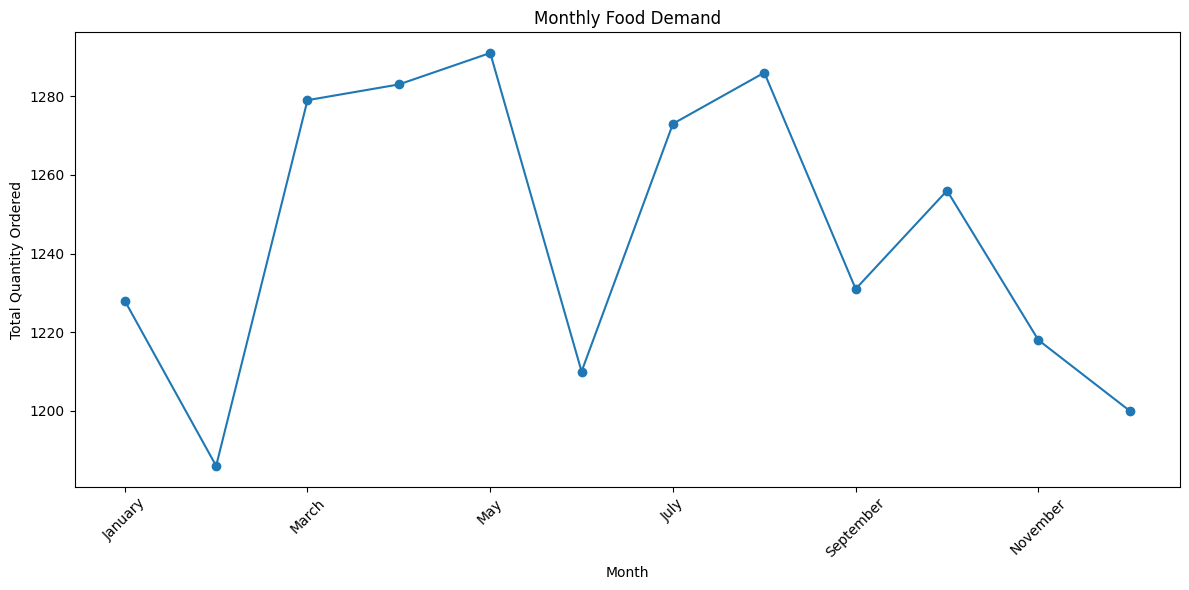

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

monthly_demand.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Food Demand")
plt.xlabel("Month")
plt.ylabel("Total Quantity Ordered")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [30]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_demand = (
    df.groupby("Day")["Quantity"]
    .sum()
    .reindex(day_order)
)

daily_demand

Day
Monday       2146
Tuesday      2134
Wednesday    2073
Thursday     2197
Friday       2100
Saturday     2145
Sunday       2146
Name: Quantity, dtype: int32

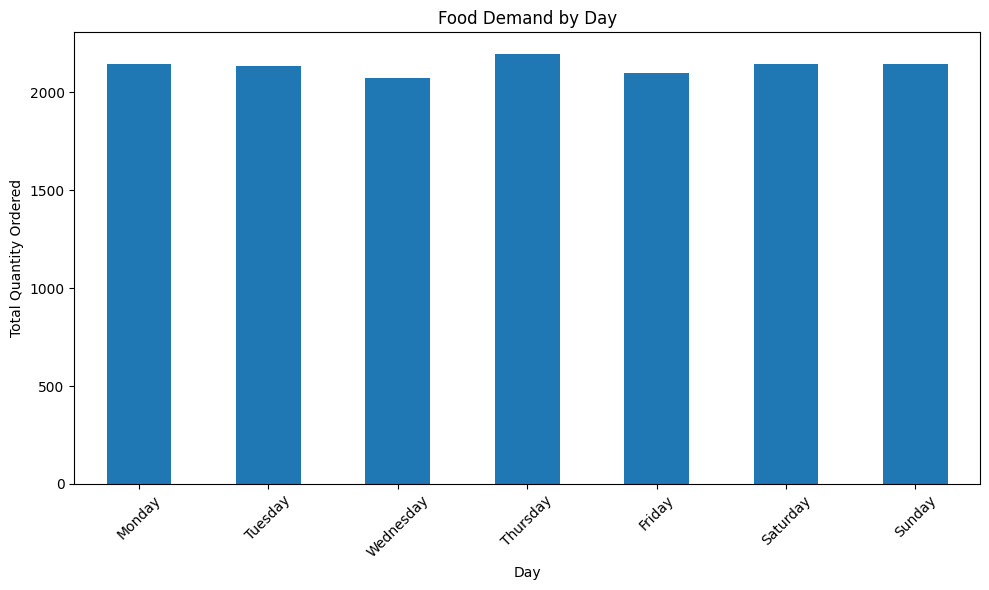

In [31]:
plt.figure(figsize=(10, 6))

daily_demand.plot(
    kind="bar"
)

plt.title("Food Demand by Day")
plt.xlabel("Day")
plt.ylabel("Total Quantity Ordered")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [32]:
meal_time_demand = (
    df.groupby("Meal_Time")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print("Demand by Meal Time:")
print(meal_time_demand)

Demand by Meal Time:
Meal_Time
Lunch        6249
Dinner       5714
Breakfast    2978
Name: Quantity, dtype: int32


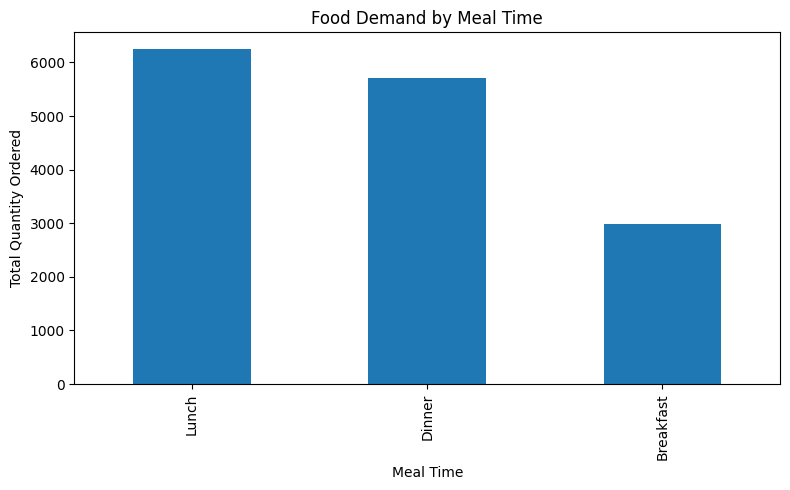

In [33]:
plt.figure(figsize=(8, 5))

meal_time_demand.plot(
    kind="bar"
)

plt.title("Food Demand by Meal Time")
plt.xlabel("Meal Time")
plt.ylabel("Total Quantity Ordered")

plt.tight_layout()
plt.show()

In [34]:
chicken_meal_demand = (
    chicken_df.groupby("Meal_Time")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print("Chicken Demand by Meal Time:")
print(chicken_meal_demand)

Chicken Demand by Meal Time:
Meal_Time
Lunch        2196
Dinner       2097
Breakfast    1101
Name: Quantity, dtype: int32


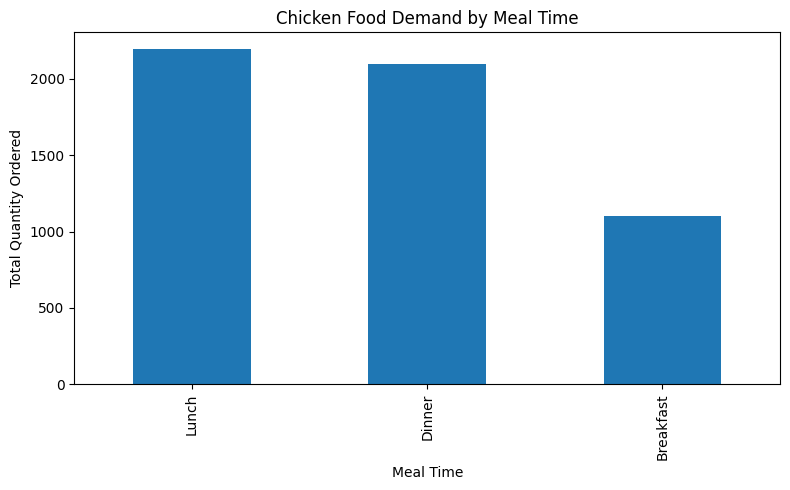

In [35]:
plt.figure(figsize=(8, 5))

chicken_meal_demand.plot(
    kind="bar"
)

plt.title("Chicken Food Demand by Meal Time")
plt.xlabel("Meal Time")
plt.ylabel("Total Quantity Ordered")

plt.tight_layout()
plt.show()

In [36]:
peak_day = daily_demand.idxmax()
peak_day_quantity = daily_demand.max()

peak_meal = meal_time_demand.idxmax()
peak_meal_quantity = meal_time_demand.max()

print("Peak Demand Day:", peak_day)
print("Quantity Ordered:", peak_day_quantity)

print("\nPeak Meal Time:", peak_meal)
print("Quantity Ordered:", peak_meal_quantity)

Peak Demand Day: Thursday
Quantity Ordered: 2197

Peak Meal Time: Lunch
Quantity Ordered: 6249


In [37]:
# Create a copy for machine learning
ml_df = df.copy()

print("ML Dataset Shape:", ml_df.shape)
ml_df.head()

ML Dataset Shape: (5000, 13)


,Order_ID,Order_Date,Food_Item,Quantity,Category,Unit_Price,Total_Amount,Day,Meal_Time,Customer_Type,Preparation_Quantity,Wasted_Quantity,Month
0,1,2025-01-01 00:00:00.000000000,Veg Biryani,5,Vegetarian,130,650,Wednesday,Breakfast,New,8,3,January
1,2,2025-01-01 01:44:51.178235647,Chicken 65,2,Chicken,140,280,Wednesday,Dinner,New,2,0,January
2,3,2025-01-01 03:29:42.356471294,Paneer Butter Masala,4,Vegetarian,170,680,Wednesday,Dinner,New,5,1,January
3,4,2025-01-01 05:14:33.534706941,Fried Rice,1,Vegetarian,120,120,Wednesday,Breakfast,Regular,3,2,January
4,5,2025-01-01 06:59:24.712942588,Parotta,3,Vegetarian,60,180,Wednesday,Breakfast,Regular,4,1,January


In [38]:
# Extract date-based features

ml_df["Year"] = ml_df["Order_Date"].dt.year
ml_df["Month_Number"] = ml_df["Order_Date"].dt.month
ml_df["Day_Number"] = ml_df["Order_Date"].dt.day
ml_df["Day_of_Week_Number"] = ml_df["Order_Date"].dt.dayofweek

print(
    ml_df[
        [
            "Order_Date",
            "Year",
            "Month_Number",
            "Day_Number",
            "Day_of_Week_Number"
        ]
    ].head()
)

                     Order_Date  Year  Month_Number  Day_Number  \
0 2025-01-01 00:00:00.000000000  2025             1           1   
1 2025-01-01 01:44:51.178235647  2025             1           1   
2 2025-01-01 03:29:42.356471294  2025             1           1   
3 2025-01-01 05:14:33.534706941  2025             1           1   
4 2025-01-01 06:59:24.712942588  2025             1           1   

   Day_of_Week_Number  
0                   2  
1                   2  
2                   2  
3                   2  
4                   2  


In [39]:
ml_df["Is_Weekend"] = (
    ml_df["Day_of_Week_Number"] >= 5
).astype(int)

ml_df[
    [
        "Day",
        "Day_of_Week_Number",
        "Is_Weekend"
    ]
].head(10)

,Day,Day_of_Week_Number,Is_Weekend
0,Wednesday,2,0
1,Wednesday,2,0
2,Wednesday,2,0
3,Wednesday,2,0
4,Wednesday,2,0
5,Wednesday,2,0
6,Wednesday,2,0
7,Wednesday,2,0
8,Wednesday,2,0
9,Wednesday,2,0


In [40]:
print("ML Dataset Columns:")
print(ml_df.columns.tolist())

ML Dataset Columns:
['Order_ID', 'Order_Date', 'Food_Item', 'Quantity', 'Category', 'Unit_Price', 'Total_Amount', 'Day', 'Meal_Time', 'Customer_Type', 'Preparation_Quantity', 'Wasted_Quantity', 'Month', 'Year', 'Month_Number', 'Day_Number', 'Day_of_Week_Number', 'Is_Weekend']


In [41]:
features = [
    "Food_Item",
    "Category",
    "Unit_Price",
    "Day",
    "Meal_Time",
    "Customer_Type",
    "Year",
    "Month_Number",
    "Day_Number",
    "Day_of_Week_Number",
    "Is_Weekend"
]

target = "Quantity"

X = ml_df[features]
y = ml_df[target]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (5000, 11)
Target Shape: (5000,)


In [42]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

Categorical Features:
['Food_Item', 'Category', 'Day', 'Meal_Time', 'Customer_Type']


In [43]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

Numerical Features:
['Unit_Price', 'Is_Weekend']


In [44]:
print("Number of Features:", len(features))
print("Target Variable:", target)

print("\nFeatures:")
for feature in features:
    print("-", feature)

Number of Features: 11
Target Variable: Quantity

Features:
- Food_Item
- Category
- Unit_Price
- Day
- Meal_Time
- Customer_Type
- Year
- Month_Number
- Day_Number
- Day_of_Week_Number
- Is_Weekend


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

print("Scikit-learn preprocessing modules imported successfully.")

Scikit-learn preprocessing modules imported successfully.


In [46]:
X = ml_df[features]
y = ml_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 11)
y shape: (5000,)


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


In [48]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Food_Item', 'Category', 'Day', 'Meal_Time', 'Customer_Type']

Numerical Features:
['Unit_Price', 'Is_Weekend']


In [49]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            encoder,
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [51]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape:", X_test_processed.shape)

Processed Training Shape: (4000, 31)
Processed Testing Shape: (1000, 31)


In [53]:
print("Original Training Shape:", X_train.shape)
print("Processed Training Shape:", X_train_processed.shape)

print("\nOriginal Testing Shape:", X_test.shape)
print("Processed Testing Shape:", X_test_processed.shape)

Original Training Shape: (4000, 11)
Processed Training Shape: (4000, 31)

Original Testing Shape: (1000, 11)
Processed Testing Shape: (1000, 31)


In [54]:
print("Training Target:")
print(y_train.head())

print("\nTesting Target:")
print(y_test.head())

Training Target:
4227    2
4676    5
800     2
3671    3
4193    5
Name: Quantity, dtype: int32

Testing Target:
1501    1
2586    5
2653    3
1055    1
705     5
Name: Quantity, dtype: int32


In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

print("Regression models imported successfully.")

Regression models imported successfully.


In [56]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

print("Models created successfully.")

Models created successfully.


In [57]:
trained_models = {}

for name, model in models.items():

    model.fit(
        X_train_processed,
        y_train
    )

    trained_models[name] = model

    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [58]:
predictions = {}

for name, model in trained_models.items():

    predictions[name] = model.predict(
        X_test_processed
    )

    print(f"{name} predictions generated.")

Linear Regression predictions generated.
Decision Tree predictions generated.
Random Forest predictions generated.
Gradient Boosting predictions generated.


In [59]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Evaluation metrics imported successfully.")

Evaluation metrics imported successfully.


In [60]:
import numpy as np

results = []

for name, prediction in predictions.items():

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    r2 = r2_score(
        y_test,
        prediction
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2_Score": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2_Score
0,Linear Regression,1.239931,1.431705,-0.000392
1,Decision Tree,1.304508,1.530142,-0.142685
2,Random Forest,1.299412,1.520708,-0.128639
3,Gradient Boosting,1.245529,1.437873,-0.009031


In [61]:
results_df = results_df.sort_values(
    "R2_Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2_Score
0,Linear Regression,1.239931,1.431705,-0.000392
1,Gradient Boosting,1.245529,1.437873,-0.009031
2,Random Forest,1.299412,1.520708,-0.128639
3,Decision Tree,1.304508,1.530142,-0.142685


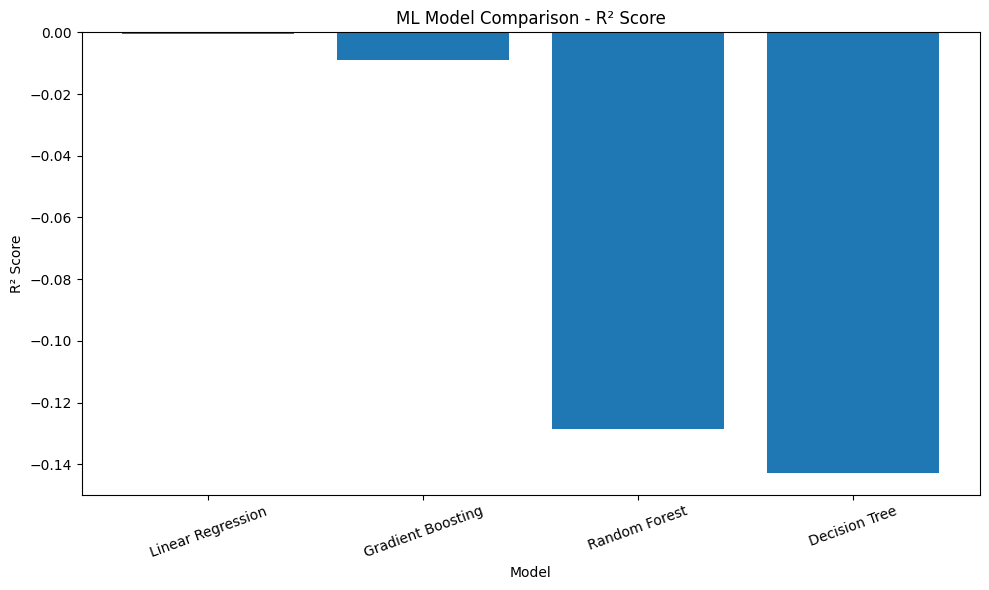

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["R2_Score"]
)

plt.title("ML Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [63]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("Best Model:", best_model_name)

Best Model: Linear Regression


In [64]:
best_result = results_df.iloc[0]

print("Best Model Performance")
print("----------------------")

print("Model:", best_result["Model"])
print("MAE:", round(best_result["MAE"], 4))
print("RMSE:", round(best_result["RMSE"], 4))
print("R² Score:", round(best_result["R2_Score"], 4))

Best Model Performance
----------------------
Model: Linear Regression
MAE: 1.2399
RMSE: 1.4317
R² Score: -0.0004


In [65]:
# Generate predictions using the selected best model

y_pred = best_model.predict(
    X_test_processed
)

print("Best Model:", best_model_name)
print("Predictions generated:", len(y_pred))

Best Model: Linear Regression
Predictions generated: 1000


In [66]:
comparison_df = pd.DataFrame({
    "Actual_Quantity": y_test.values,
    "Predicted_Quantity": y_pred
})

comparison_df.head(20)

,Actual_Quantity,Predicted_Quantity
0,1,2.931458
1,5,2.946468
2,3,2.962158
3,1,2.977489
4,5,2.952250
5,1,3.037659
6,2,2.817752
7,3,2.892383
8,1,2.814363
9,4,2.903267


In [67]:
comparison_df["Prediction_Error"] = (
    comparison_df["Actual_Quantity"]
    - comparison_df["Predicted_Quantity"]
)

comparison_df["Absolute_Error"] = (
    comparison_df["Prediction_Error"].abs()
)

comparison_df.head(20)

,Actual_Quantity,Predicted_Quantity,Prediction_Error,Absolute_Error
0,1,2.931458,-1.931458,1.931458
1,5,2.946468,2.053532,2.053532
2,3,2.962158,0.037842,0.037842
3,1,2.977489,-1.977489,1.977489
4,5,2.952250,2.047750,2.047750
5,1,3.037659,-2.037659,2.037659
6,2,2.817752,-0.817752,0.817752
7,3,2.892383,0.107617,0.107617
8,1,2.814363,-1.814363,1.814363
9,4,2.903267,1.096733,1.096733


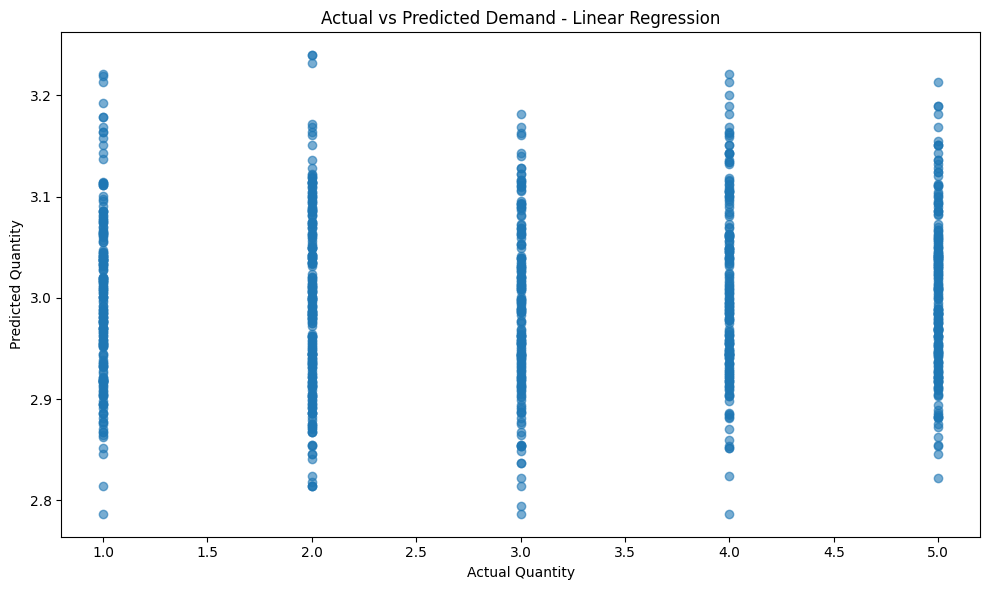

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    comparison_df["Actual_Quantity"],
    comparison_df["Predicted_Quantity"],
    alpha=0.6
)

plt.xlabel("Actual Quantity")
plt.ylabel("Predicted Quantity")

plt.title(
    f"Actual vs Predicted Demand - {best_model_name}"
)

plt.tight_layout()
plt.show()

In [69]:
average_error = comparison_df[
    "Absolute_Error"
].mean()

print(
    "Average Absolute Prediction Error:",
    round(average_error, 4)
)

Average Absolute Prediction Error: 1.2399


In [70]:
high_error_predictions = (
    comparison_df
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(10)
)

high_error_predictions

,Actual_Quantity,Predicted_Quantity,Prediction_Error,Absolute_Error
799,1,3.221222,-2.221222,2.221222
538,1,3.219021,-2.219021,2.219021
227,1,3.213343,-2.213343,2.213343
339,1,3.192810,-2.192810,2.192810
793,1,3.178679,-2.178679,2.178679
822,1,3.178679,-2.178679,2.178679
18,5,2.822242,2.177758,2.177758
883,1,3.168226,-2.168226,2.168226
327,1,3.163321,-2.163321,2.163321
529,1,3.163321,-2.163321,2.163321


In [71]:
prediction_analysis = X_test.copy()

prediction_analysis["Actual_Quantity"] = (
    y_test.values
)

prediction_analysis["Predicted_Quantity"] = (
    y_pred
)

prediction_analysis["Absolute_Error"] = (
    prediction_analysis["Actual_Quantity"]
    - prediction_analysis["Predicted_Quantity"]
).abs()

prediction_analysis.head()

,Food_Item,Category,Unit_Price,Day,Meal_Time,Customer_Type,Year,Month_Number,Day_Number,Day_of_Week_Number,Is_Weekend,Actual_Quantity,Predicted_Quantity,Absolute_Error
1501,Chicken Biryani,Chicken,180,Sunday,Dinner,Regular,2025,4,20,6,1,1,2.931458,1.931458
2586,Dosa,Vegetarian,50,Tuesday,Dinner,Regular,2025,7,8,1,0,5,2.946468,2.053532
2653,Chicken Fried Rice,Chicken,160,Sunday,Breakfast,Regular,2025,7,13,6,1,3,2.962158,0.037842
1055,Dosa,Vegetarian,50,Tuesday,Lunch,Regular,2025,3,18,1,0,1,2.977489,1.977489
705,Chicken Noodles,Chicken,150,Friday,Dinner,New,2025,2,21,4,0,5,2.952250,2.047750


In [72]:
food_prediction_accuracy = (
    prediction_analysis
    .groupby("Food_Item")
    .agg(
        Actual_Demand=(
            "Actual_Quantity",
            "mean"
        ),
        Predicted_Demand=(
            "Predicted_Quantity",
            "mean"
        ),
        Average_Error=(
            "Absolute_Error",
            "mean"
        )
    )
    .sort_values(
        "Average_Error",
        ascending=False
    )
)

food_prediction_accuracy

,Actual_Demand,Predicted_Demand,Average_Error
Food_Item,,,
Chicken Noodles,3.238806,3.023998,1.406273
Parotta,2.987952,2.982757,1.369505
Dosa,3.140845,3.021482,1.337367
Paneer Butter Masala,3.185714,3.111041,1.297364
Idli,2.883117,3.101413,1.256541
Noodles,2.869565,2.992255,1.242155
Chicken Biryani,2.927536,2.964822,1.239305
Veg Biryani,2.727273,3.041926,1.235518
Veg Meals,2.819672,3.034531,1.216704


In [73]:
chicken_prediction_accuracy = (
    prediction_analysis[
        prediction_analysis["Category"] == "Chicken"
    ]
    .groupby("Food_Item")
    .agg(
        Actual_Demand=(
            "Actual_Quantity",
            "mean"
        ),
        Predicted_Demand=(
            "Predicted_Quantity",
            "mean"
        ),
        Average_Error=(
            "Absolute_Error",
            "mean"
        )
    )
    .sort_values(
        "Average_Error",
        ascending=False
    )
)

chicken_prediction_accuracy

,Actual_Demand,Predicted_Demand,Average_Error
Food_Item,,,
Chicken Noodles,3.238806,3.023998,1.406273
Chicken Biryani,2.927536,2.964822,1.239305
Chicken 65,2.952381,2.901648,1.198813
Chicken Fried Rice,2.972603,2.906476,1.155003
Chicken Grill,3.014286,2.976644,1.079984


In [74]:
results_path = "../outputs/model_comparison.csv"

results_df.to_csv(
    results_path,
    index=False
)

print("Model comparison saved successfully!")
print(results_path)

Model comparison saved successfully!
../outputs/model_comparison.csv


In [75]:
prediction_path = "../outputs/demand_predictions.csv"

prediction_analysis.to_csv(
    prediction_path,
    index=False
)

print("Demand predictions saved successfully!")
print(prediction_path)

Demand predictions saved successfully!
../outputs/demand_predictions.csv


In [76]:
import joblib
import os

print("Joblib imported successfully.")

Joblib imported successfully.


In [77]:
models_folder = "../models"

os.makedirs(
    models_folder,
    exist_ok=True
)

print("Models folder is ready.")

Models folder is ready.


In [78]:
model_path = "../models/best_demand_model.pkl"

joblib.dump(
    best_model,
    model_path
)

print("Best model saved successfully!")
print(model_path)

Best model saved successfully!
../models/best_demand_model.pkl


In [79]:
preprocessor_path = "../models/demand_preprocessor.pkl"

joblib.dump(
    preprocessor,
    preprocessor_path
)

print("Preprocessor saved successfully!")
print(preprocessor_path)

Preprocessor saved successfully!
../models/demand_preprocessor.pkl


In [80]:
features_path = "../models/demand_features.pkl"

joblib.dump(
    features,
    features_path
)

print("Feature list saved successfully!")
print(features_path)

Feature list saved successfully!
../models/demand_features.pkl


In [81]:
print("Saved Model Files:")

for file in os.listdir(models_folder):
    print("-", file)

Saved Model Files:
- best_demand_model.pkl
- demand_features.pkl
- demand_preprocessor.pkl


In [82]:
loaded_model = joblib.load(
    "../models/best_demand_model.pkl"
)

loaded_preprocessor = joblib.load(
    "../models/demand_preprocessor.pkl"
)

loaded_features = joblib.load(
    "../models/demand_features.pkl"
)

print("Model loaded successfully!")
print("Preprocessor loaded successfully!")
print("Features loaded successfully!")

Model loaded successfully!
Preprocessor loaded successfully!
Features loaded successfully!


In [83]:
sample_data = X_test.head(5)

sample_processed = loaded_preprocessor.transform(
    sample_data
)

sample_predictions = loaded_model.predict(
    sample_processed
)

print("Sample Predictions:")

for prediction in sample_predictions:
    print(round(prediction, 2))

Sample Predictions:
2.93
2.95
2.96
2.98
2.95


In [84]:
recommendation_df = (
    df.groupby("Food_Item")
    .agg(
        Total_Ordered=("Quantity", "sum"),
        Total_Prepared=("Preparation_Quantity", "sum"),
        Total_Wasted=("Wasted_Quantity", "sum"),
        Total_Revenue=("Total_Amount", "sum")
    )
    .reset_index()
)

recommendation_df["Waste_Percentage"] = (
    recommendation_df["Total_Wasted"]
    / recommendation_df["Total_Prepared"]
    * 100
)

recommendation_df

,Food_Item,Total_Ordered,Total_Prepared,Total_Wasted,Total_Revenue,Waste_Percentage
0,Chicken 65,998,1515,517,139720,34.125413
1,Chicken Biryani,1118,1678,560,201240,33.373063
2,Chicken Fried Rice,1022,1568,546,163520,34.821429
3,Chicken Grill,1131,1702,571,248820,33.548766
4,Chicken Noodles,1125,1640,515,168750,31.402439
5,Dosa,1068,1586,518,53400,32.660782
6,Fried Rice,930,1421,491,111600,34.553132
7,Idli,1045,1584,539,41800,34.027778
8,Mutton Biryani,1052,1617,565,252480,34.941249
9,Noodles,1184,1770,586,130240,33.107345


In [85]:
demand_threshold = recommendation_df[
    "Total_Ordered"
].median()

print("Demand Threshold:", demand_threshold)

Demand Threshold: 1061.0


In [86]:
recommendation_df["Demand_Level"] = np.where(
    recommendation_df["Total_Ordered"] >= demand_threshold,
    "High Demand",
    "Low Demand"
)

recommendation_df[
    [
        "Food_Item",
        "Total_Ordered",
        "Demand_Level"
    ]
]

,Food_Item,Total_Ordered,Demand_Level
0,Chicken 65,998,Low Demand
1,Chicken Biryani,1118,High Demand
2,Chicken Fried Rice,1022,Low Demand
3,Chicken Grill,1131,High Demand
4,Chicken Noodles,1125,High Demand
5,Dosa,1068,High Demand
6,Fried Rice,930,Low Demand
7,Idli,1045,Low Demand
8,Mutton Biryani,1052,Low Demand
9,Noodles,1184,High Demand


In [87]:
recommendation_df["Waste_Level"] = np.where(
    recommendation_df["Waste_Percentage"] > 10,
    "High Waste",
    "Low Waste"
)

recommendation_df[
    [
        "Food_Item",
        "Waste_Percentage",
        "Waste_Level"
    ]
]

,Food_Item,Waste_Percentage,Waste_Level
0,Chicken 65,34.125413,High Waste
1,Chicken Biryani,33.373063,High Waste
2,Chicken Fried Rice,34.821429,High Waste
3,Chicken Grill,33.548766,High Waste
4,Chicken Noodles,31.402439,High Waste
5,Dosa,32.660782,High Waste
6,Fried Rice,34.553132,High Waste
7,Idli,34.027778,High Waste
8,Mutton Biryani,34.941249,High Waste
9,Noodles,33.107345,High Waste


In [88]:
def generate_recommendation(row):

    if (
        row["Demand_Level"] == "High Demand"
        and row["Waste_Level"] == "Low Waste"
    ):
        return "Increase Preparation"

    elif (
        row["Demand_Level"] == "High Demand"
        and row["Waste_Level"] == "High Waste"
    ):
        return "Optimize Preparation"

    elif (
        row["Demand_Level"] == "Low Demand"
        and row["Waste_Level"] == "High Waste"
    ):
        return "Reduce Preparation"

    else:
        return "Monitor"

In [89]:
recommendation_df["Recommendation"] = (
    recommendation_df.apply(
        generate_recommendation,
        axis=1
    )
)

recommendation_df

,Food_Item,Total_Ordered,Total_Prepared,Total_Wasted,Total_Revenue,Waste_Percentage,Demand_Level,Waste_Level,Recommendation
0,Chicken 65,998,1515,517,139720,34.125413,Low Demand,High Waste,Reduce Preparation
1,Chicken Biryani,1118,1678,560,201240,33.373063,High Demand,High Waste,Optimize Preparation
2,Chicken Fried Rice,1022,1568,546,163520,34.821429,Low Demand,High Waste,Reduce Preparation
3,Chicken Grill,1131,1702,571,248820,33.548766,High Demand,High Waste,Optimize Preparation
4,Chicken Noodles,1125,1640,515,168750,31.402439,High Demand,High Waste,Optimize Preparation
5,Dosa,1068,1586,518,53400,32.660782,High Demand,High Waste,Optimize Preparation
6,Fried Rice,930,1421,491,111600,34.553132,Low Demand,High Waste,Reduce Preparation
7,Idli,1045,1584,539,41800,34.027778,Low Demand,High Waste,Reduce Preparation
8,Mutton Biryani,1052,1617,565,252480,34.941249,Low Demand,High Waste,Reduce Preparation
9,Noodles,1184,1770,586,130240,33.107345,High Demand,High Waste,Optimize Preparation


In [90]:
final_recommendations = recommendation_df[
    [
        "Food_Item",
        "Total_Ordered",
        "Total_Prepared",
        "Total_Wasted",
        "Waste_Percentage",
        "Total_Revenue",
        "Demand_Level",
        "Waste_Level",
        "Recommendation"
    ]
].sort_values(
    "Total_Ordered",
    ascending=False
)

final_recommendations

,Food_Item,Total_Ordered,Total_Prepared,Total_Wasted,Waste_Percentage,Total_Revenue,Demand_Level,Waste_Level,Recommendation
9,Noodles,1184,1770,586,33.107345,130240,High Demand,High Waste,Optimize Preparation
3,Chicken Grill,1131,1702,571,33.548766,248820,High Demand,High Waste,Optimize Preparation
4,Chicken Noodles,1125,1640,515,31.402439,168750,High Demand,High Waste,Optimize Preparation
1,Chicken Biryani,1118,1678,560,33.373063,201240,High Demand,High Waste,Optimize Preparation
10,Paneer Butter Masala,1118,1629,511,31.368938,190060,High Demand,High Waste,Optimize Preparation
11,Parotta,1096,1668,572,34.292566,65760,High Demand,High Waste,Optimize Preparation
5,Dosa,1068,1586,518,32.660782,53400,High Demand,High Waste,Optimize Preparation
13,Veg Meals,1054,1622,568,35.018496,105400,Low Demand,High Waste,Reduce Preparation
8,Mutton Biryani,1052,1617,565,34.941249,252480,Low Demand,High Waste,Reduce Preparation
7,Idli,1045,1584,539,34.027778,41800,Low Demand,High Waste,Reduce Preparation


In [91]:
recommendation_counts = (
    recommendation_df["Recommendation"]
    .value_counts()
)

recommendation_counts

Recommendation
Reduce Preparation      7
Optimize Preparation    7
Name: count, dtype: int64

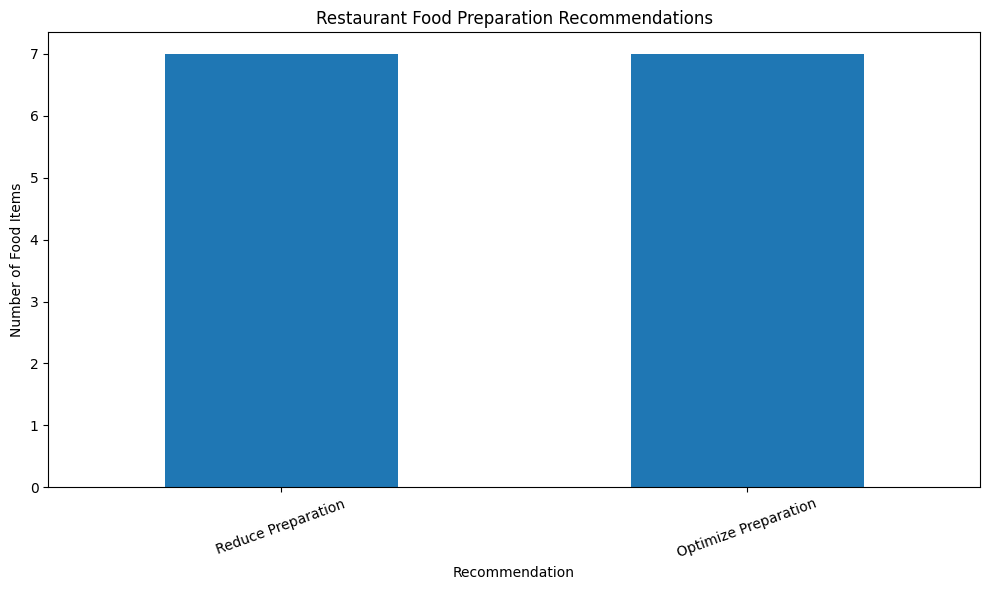

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

recommendation_counts.plot(
    kind="bar"
)

plt.title("Restaurant Food Preparation Recommendations")
plt.xlabel("Recommendation")
plt.ylabel("Number of Food Items")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [93]:
high_waste_items = recommendation_df[
    recommendation_df["Waste_Level"] == "High Waste"
].sort_values(
    "Waste_Percentage",
    ascending=False
)

print("High-Waste Items:")
print(high_waste_items)

High-Waste Items:
               Food_Item  Total_Ordered  Total_Prepared  Total_Wasted  \
13             Veg Meals           1054            1622           568   
8         Mutton Biryani           1052            1617           565   
2     Chicken Fried Rice           1022            1568           546   
6             Fried Rice            930            1421           491   
11               Parotta           1096            1668           572   
0             Chicken 65            998            1515           517   
7                   Idli           1045            1584           539   
3          Chicken Grill           1131            1702           571   
12           Veg Biryani           1000            1502           502   
1        Chicken Biryani           1118            1678           560   
9                Noodles           1184            1770           586   
5                   Dosa           1068            1586           518   
4        Chicken Noodles         

In [94]:
high_demand_items = recommendation_df[
    recommendation_df["Demand_Level"] == "High Demand"
].sort_values(
    "Total_Ordered",
    ascending=False
)

print("High-Demand Items:")
print(high_demand_items)

High-Demand Items:
               Food_Item  Total_Ordered  Total_Prepared  Total_Wasted  \
9                Noodles           1184            1770           586   
3          Chicken Grill           1131            1702           571   
4        Chicken Noodles           1125            1640           515   
1        Chicken Biryani           1118            1678           560   
10  Paneer Butter Masala           1118            1629           511   
11               Parotta           1096            1668           572   
5                   Dosa           1068            1586           518   

    Total_Revenue  Waste_Percentage Demand_Level Waste_Level  \
9          130240         33.107345  High Demand  High Waste   
3          248820         33.548766  High Demand  High Waste   
4          168750         31.402439  High Demand  High Waste   
1          201240         33.373063  High Demand  High Waste   
10         190060         31.368938  High Demand  High Waste   
11          

In [95]:
reduce_preparation = recommendation_df[
    recommendation_df["Recommendation"] == "Reduce Preparation"
]

print("Items Recommended for Reduced Preparation:")
print(reduce_preparation)

Items Recommended for Reduced Preparation:
             Food_Item  Total_Ordered  Total_Prepared  Total_Wasted  \
0           Chicken 65            998            1515           517   
2   Chicken Fried Rice           1022            1568           546   
6           Fried Rice            930            1421           491   
7                 Idli           1045            1584           539   
8       Mutton Biryani           1052            1617           565   
12         Veg Biryani           1000            1502           502   
13           Veg Meals           1054            1622           568   

    Total_Revenue  Waste_Percentage Demand_Level Waste_Level  \
0          139720         34.125413   Low Demand  High Waste   
2          163520         34.821429   Low Demand  High Waste   
6          111600         34.553132   Low Demand  High Waste   
7           41800         34.027778   Low Demand  High Waste   
8          252480         34.941249   Low Demand  High Waste   
12  

In [96]:
chicken_recommendations = recommendation_df[
    recommendation_df["Food_Item"].isin(
        chicken_df["Food_Item"].unique()
    )
].sort_values(
    "Total_Ordered",
    ascending=False
)

chicken_recommendations

,Food_Item,Total_Ordered,Total_Prepared,Total_Wasted,Total_Revenue,Waste_Percentage,Demand_Level,Waste_Level,Recommendation
3,Chicken Grill,1131,1702,571,248820,33.548766,High Demand,High Waste,Optimize Preparation
4,Chicken Noodles,1125,1640,515,168750,31.402439,High Demand,High Waste,Optimize Preparation
1,Chicken Biryani,1118,1678,560,201240,33.373063,High Demand,High Waste,Optimize Preparation
2,Chicken Fried Rice,1022,1568,546,163520,34.821429,Low Demand,High Waste,Reduce Preparation
0,Chicken 65,998,1515,517,139720,34.125413,Low Demand,High Waste,Reduce Preparation


In [97]:
recommendation_path = (
    "../outputs/food_recommendations.csv"
)

final_recommendations.to_csv(
    recommendation_path,
    index=False
)

print("Recommendation report saved successfully!")
print(recommendation_path)

Recommendation report saved successfully!
../outputs/food_recommendations.csv


In [98]:
import os

processed_folder = "../data/processed"

os.makedirs(
    processed_folder,
    exist_ok=True
)

print("Processed data folder is ready.")

Processed data folder is ready.


In [99]:
processed_dataset_path = (
    "../data/processed/restaurant_ml_dataset.csv"
)

ml_df.to_csv(
    processed_dataset_path,
    index=False
)

print("ML dataset saved successfully!")
print(processed_dataset_path)

ML dataset saved successfully!
../data/processed/restaurant_ml_dataset.csv


In [100]:
demand_analysis_path = (
    "../outputs/food_demand_analysis.csv"
)

demand_analysis.to_csv(
    demand_analysis_path
)

print("Demand analysis saved successfully!")

Demand analysis saved successfully!


In [101]:
waste_analysis_path = (
    "../outputs/food_waste_analysis.csv"
)

waste_analysis.to_csv(
    waste_analysis_path
)

print("Waste analysis saved successfully!")

Waste analysis saved successfully!


In [102]:
chicken_analysis_path = (
    "../outputs/chicken_food_analysis.csv"
)

chicken_business_analysis.to_csv(
    chicken_analysis_path
)

print("Chicken analysis saved successfully!")

Chicken analysis saved successfully!


In [103]:
monthly_demand_path = (
    "../outputs/monthly_demand.csv"
)

monthly_demand.to_csv(
    monthly_demand_path,
    header=["Total_Quantity"]
)

print("Monthly demand saved successfully!")

Monthly demand saved successfully!


In [104]:
daily_demand_path = (
    "../outputs/daily_demand.csv"
)

daily_demand.to_csv(
    daily_demand_path,
    header=["Total_Quantity"]
)

print("Daily demand saved successfully!")

Daily demand saved successfully!


In [105]:
total_orders = df["Quantity"].sum()

total_prepared = df[
    "Preparation_Quantity"
].sum()

total_wasted = df[
    "Wasted_Quantity"
].sum()

total_revenue = df[
    "Total_Amount"
].sum()

overall_waste_percentage = (
    total_wasted
    / total_prepared
    * 100
)

number_of_food_items = (
    df["Food_Item"].nunique()
)

summary = pd.DataFrame({
    "Metric": [
        "Total Food Quantity Ordered",
        "Total Food Prepared",
        "Total Food Wasted",
        "Total Revenue",
        "Overall Waste Percentage",
        "Number of Food Items"
    ],
    "Value": [
        total_orders,
        total_prepared,
        total_wasted,
        total_revenue,
        round(overall_waste_percentage, 2),
        number_of_food_items
    ]
})

summary

,Metric,Value
0,Total Food Quantity Ordered,14941.0
1,Total Food Prepared,22502.0
2,Total Food Wasted,7561.0
3,Total Revenue,2002790.0
4,Overall Waste Percentage,33.6
5,Number of Food Items,14.0


In [106]:
summary_path = (
    "../outputs/project_summary.csv"
)

summary.to_csv(
    summary_path,
    index=False
)

print("Project summary saved successfully!")

Project summary saved successfully!


In [107]:
print("Output Files:")

for file in sorted(os.listdir("../outputs")):
    print("-", file)

Output Files:
- chicken_food_analysis.csv
- daily_demand.csv
- demand_predictions.csv
- food_demand_analysis.csv
- food_recommendations.csv
- food_waste_analysis.csv
- model_comparison.csv
- monthly_demand.csv
- project_summary.csv
